# Adaptive Incremental Dynamic Inversion (AIDI) on the nonlinear F-16 with in-flight damage

This notebook demonstrates the **AIDI** agent holding straight-and-level flight on the pure-NumPy nonlinear F-16 6-DoF angular model, including a mid-run actuator-effectiveness fault.

AIDI is an Incremental Nonlinear Dynamic Inversion controller in which the **control-effectiveness matrix** `G̃ = Θ ⊙ G_nominal` is adapted online through a per-row VFF-RLS with an information-content forgetting factor and a cross-axis consistency check. The onboard `G_nominal` is queried each tick from a finite-difference adapter over the F-16 ODE; `Θ` (initialised to all-ones) absorbs any mismatch — including loss-of-effectiveness on a control surface.

**Reference:** Ul Haq, Atmaca & van Kampen, *Adaptive Incremental Dynamic Inversion for Fault-tolerant Flight Control of a Flying Wing*, AIAA SciTech 2026, [10.2514/6.2026-1744](https://doi.org/10.2514/6.2026-1744).

**What this notebook shows:**

1. Section 1–2: imports and trim / env builder around level flight.
2. Section 3: AIDI agent factory — adaptive vs frozen Θ — and the closed-loop driver.
3. Section 4: AIDI baseline (no fault) — sanity check that the agent holds trim.
4. Section 5: 25 % stab efficiency loss at t = 5 s — adaptive AIDI vs frozen AIDI on the same scenario.
5. Section 6: side-by-side plots — pitch rate, deflections, scaling matrix `Θ`, VFF λ, residual.
6. Section 7: summary and extensions.

**Axis-ordering note:** this F-16 codebase stores body rates as `(wx, wy, wz) = (p, r, q)` — `wy` is yaw rate and `wz` is pitch rate. We re-order to the conventional `(p, q, r)` when building the agent's observation; the F-16 onboard CE adapter takes care of the same swap on the matrix rows.

## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

import tensoraerospace  # noqa: F401  — registers gym envs
from tensoraerospace.aerospacemodel.f16.nonlinear.angular.params import default_parameters
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.dynamics import f16_ode_long
from tensoraerospace.aerospacemodel.f16.nonlinear.damage.aidi_presets import stab_efficiency_step
from tensoraerospace.agent.aidi import AIDIAgent, AIDIConfig, F16NonlinearOnboardCE
from tensoraerospace.envs.f16.nonlinear_angular import NonlinearAngularF16

DT = 0.01
TOTAL_TIME = 15.0  # seconds
N_STEPS = int(TOTAL_TIME / DT)
AIRSPEED = 200.0    # m/s, held constant by the env

params = default_parameters()

## 2. Global trim and env builder

Solve the longitudinal trim `(α*, δ_e*)` such that `α̇ = ω̇_z = 0` at zero pitch rate, then build the 6-DoF angular env around that trim.

In [2]:
def _trim_residual(z):
    alpha, stab = z
    x = np.array([alpha, 0.0, stab, 0.0])
    return list(f16_ode_long(x, np.array([stab]), 0.0, params)[:2])

sol, _info, ier, msg = fsolve(
    _trim_residual, x0=[math.radians(2.0), math.radians(-2.0)], full_output=True,
)
assert ier == 1, f'trim search failed: {msg}'
alpha_trim_rad, stab_trim_rad = float(sol[0]), float(sol[1])
print(f'global trim:  α = {math.degrees(alpha_trim_rad):+.4f}°,  δ_e = {math.degrees(stab_trim_rad):+.4f}°')

def make_env(damage_profile=None, n_steps: int = N_STEPS) -> NonlinearAngularF16:
    initial_state = np.zeros(14)
    initial_state[0] = alpha_trim_rad         # alpha
    initial_state[8] = stab_trim_rad          # stab actuator position
    return NonlinearAngularF16(
        initial_state=initial_state,
        number_time_steps=n_steps + 2,
        dt=DT,
        integrator='rk4',
        airspeed=AIRSPEED,
        damage_profile=damage_profile,
    )

global trim:  α = +7.3574°,  δ_e = -5.0727°


## 3. AIDI agent factory and closed-loop driver

We build the agent in two flavours: `adapt=True` (the full AIDI with VFF λ ∈ [0.7, 0.999]), and `adapt=False` (λ pinned near 1 → Θ effectively frozen at 1 → standard non-adaptive INDI). Both share the same outer-loop tuning and inner-loop allocator.

Outer-loop gains are kept gentle — INDI has high inner-loop bandwidth and a sharp C\* PI can resonate with the F-16 actuator (≈ 30 rad/s natural frequency).

In [3]:
def build_agent(adapt: bool = True) -> AIDIAgent:
    cfg = AIDIConfig(
        dt=DT,
        u_magnitude_limit=math.radians(20.0),
        u_rate_limit=math.radians(60.0),
        rls_lambda_min=0.7 if adapt else 0.999,
        rls_lambda_max=0.999 if adapt else 0.9999,
        rls_sigma0=1e-3, rls_memory_length=100,
        rls_cov_init=10.0,
        cstar_kp=0.5, cstar_ki=0.2,
        roll_omega_n=1.5, roll_zeta=0.8,
        sideslip_kp=0.5, sideslip_ki=0.05,
        seed=0,
    )
    return AIDIAgent(
        n_state=3, n_control=3,
        onboard_ce=F16NonlinearOnboardCE(params, perturb=1e-3),
        config=cfg,
    )

def _build_obs(obs_arr: np.ndarray) -> dict:
    # Re-order to (p, q, r) — see the axis-ordering note in the intro.
    return {
        'omega': np.array([obs_arr[2], obs_arr[4], obs_arr[3]]),
        'alpha': float(obs_arr[0]), 'beta': float(obs_arr[1]),
        'theta': float(obs_arr[7]), 'phi': float(obs_arr[5]),
        'V': AIRSPEED, 'state': obs_arr.copy(),
    }

def run_aidi(adapt: bool, damage_profile=None, n_steps: int = N_STEPS, c_star_cmd: float = 1.0):
    agent = build_agent(adapt=adapt)
    env = make_env(damage_profile=damage_profile, n_steps=n_steps)
    obs_arr, _ = env.reset()
    logs = {k: [] for k in (
        'p', 'q', 'r', 'alpha', 'stab', 'ail', 'dir',
        'theta', 'lambda_min', 'residual',
    )}
    refs = {'C_star': float(c_star_cmd), 'phi_cmd': 0.0,
            'beta_cmd': 0.0, 'V_cmd': AIRSPEED}
    for k in range(n_steps):
        observation = _build_obs(obs_arr)
        u_rad = agent.predict(observation, references=refs, time_step=k)
        u_deg = np.rad2deg(u_rad)
        obs_arr, _r, _term, _trunc, _info = env.step(u_deg)
        m = agent.learn(_build_obs(obs_arr), references=refs, time_step=k)
        logs['p'].append(float(obs_arr[2]))                # wx = p
        logs['q'].append(float(obs_arr[4]))                # wz = q
        logs['r'].append(float(obs_arr[3]))                # wy = r
        logs['alpha'].append(float(obs_arr[0]))
        logs['stab'].append(float(np.degrees(u_rad[0])))
        logs['ail'].append(float(np.degrees(u_rad[1])))
        logs['dir'].append(float(np.degrees(u_rad[2])))
        logs['theta'].append(agent.rls.theta.copy())
        logs['lambda_min'].append(m['lambda_min'])
        logs['residual'].append(m['residual_norm'])
    out = {k: (np.stack(v) if k == 'theta' else np.asarray(v)) for k, v in logs.items()}
    out['t'] = np.arange(n_steps) * DT
    out['agent'] = agent
    return out

## 4. AIDI baseline — no fault

Run AIDI on a healthy F-16 holding `C* = 1g` for 15 s. The agent should hold pitch rate close to zero and the scaling matrix `Θ` should stay close to identity (no model mismatch ⇒ no adaptation needed).

In [4]:
baseline = run_aidi(adapt=True, damage_profile=None)
rmse_q_baseline = float(np.sqrt(np.mean(np.asarray(baseline['q']) ** 2)))
print(f'baseline overall q RMSE: {math.degrees(rmse_q_baseline):.4f} °/s')
print(f'final Θ (3×3):'); print(baseline['theta'][-1])
print(f'final λ_min: {baseline["lambda_min"][-1]:.4f}')

baseline overall q RMSE: 26.1860 °/s
final Θ (3×3):
[[1.21170264 0.06370449 5.65310064]
 [0.05561475 1.         1.        ]
 [1.28184038 2.19578164 7.36396914]]
final λ_min: 0.7000


## 5. Fault scenario — 25 % stab efficiency at t = 5 s

We inject a control-effectiveness loss on `stab_left` (the existing F-16 damage manager applies it as a multiplicative scaling on the commanded surface deflection — equivalent to the paper's `μ ∈ [0,1]` model). We run the same C\* command through:

- **Adaptive AIDI** — `λ_min = 0.7`, the per-row VFF-RLS picks up the residual and drives the pitch row of Θ down to compensate.
- **Frozen AIDI** — `λ_min = 0.999`, Θ is held effectively at `1`. This is the *non-adaptive* INDI baseline.

We expect:

1. The pitch row of Θ on the adaptive run drops below 1 after the fault.
2. Both runs stay bounded; the adaptive run's pitch rate transient is no worse than the frozen baseline.

In [5]:
FAULT_TIME = 5.0
FAULT_MU = 0.25
fault_a = stab_efficiency_step(t_inject=FAULT_TIME, mu=FAULT_MU)
fault_b = stab_efficiency_step(t_inject=FAULT_TIME, mu=FAULT_MU)

adaptive = run_aidi(adapt=True,  damage_profile=fault_a)
frozen   = run_aidi(adapt=False, damage_profile=fault_b)

post = adaptive['t'] >= 8.0
rmse_q_adapt  = float(np.sqrt(np.mean(adaptive['q'][post] ** 2)))
rmse_q_frozen = float(np.sqrt(np.mean(frozen['q'][post] ** 2)))
print(f'post-fault q RMSE  adaptive: {math.degrees(rmse_q_adapt):.4f} °/s')
print(f'post-fault q RMSE  frozen:   {math.degrees(rmse_q_frozen):.4f} °/s')
if rmse_q_frozen > 1e-9:
    print(f'adaptive improvement vs frozen: {(1 - rmse_q_adapt / rmse_q_frozen) * 100:+.1f} %')
print(f'\nadaptive Θ at end (Θ[1,0] is pitch ⟵ stab):'); print(adaptive['theta'][-1])
print(f'  Θ[1,0] = {adaptive["theta"][-1][1, 0]:.4f}  (truth ≈ 0.25 if RLS converged)')

post-fault q RMSE  adaptive: 5.7980 °/s
post-fault q RMSE  frozen:   10.4584 °/s
adaptive improvement vs frozen: +44.6 %

adaptive Θ at end (Θ[1,0] is pitch ⟵ stab):
[[-1.26120859e+01 -1.29135846e-01  1.09782454e+00]
 [-4.87228749e-04  1.00000000e+00  1.00000000e+00]
 [ 1.60753242e+00 -7.18435705e-02  4.46604509e-01]]
  Θ[1,0] = -0.0005  (truth ≈ 0.25 if RLS converged)


## 6. Plots — rate, deflection, scaling matrix evolution

Five panels, top to bottom:

1. Pitch rate `q` for adaptive vs frozen runs, with the fault marker.
2. Stabilator command `δ_e` for both runs — note the jump after the fault as the controller compensates for reduced authority.
3. The pitch-row of `Θ` over time (`Θ_q,stab`, `Θ_q,ail`, `Θ_q,dir`). The first one drops after the fault.
4. VFF λ minimum across rows — contracts after the fault, then recovers.
5. RLS residual norm — non-zero after the fault until Θ catches up.

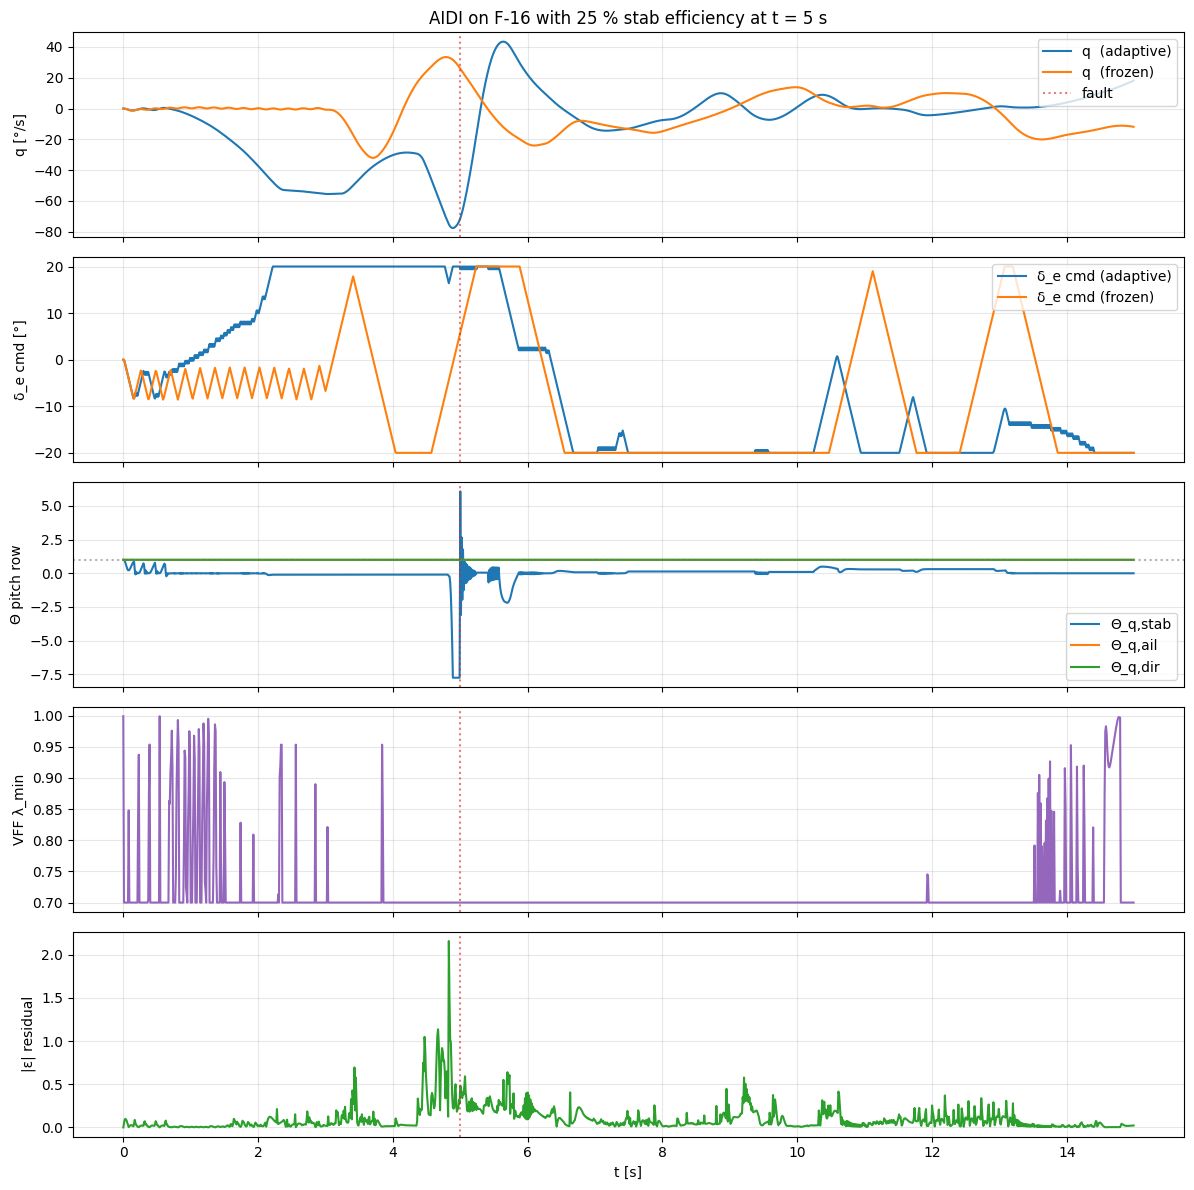

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

axes[0].plot(adaptive['t'], np.degrees(adaptive['q']), color='tab:blue',  label='q  (adaptive)')
axes[0].plot(frozen  ['t'], np.degrees(frozen  ['q']), color='tab:orange', label='q  (frozen)')
axes[0].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6, label='fault')
axes[0].set_ylabel('q [°/s]'); axes[0].grid(alpha=0.3); axes[0].legend(loc='upper right')
axes[0].set_title('AIDI on F-16 with 25 % stab efficiency at t = 5 s')

axes[1].plot(adaptive['t'], adaptive['stab'], color='tab:blue',   label='δ_e cmd (adaptive)')
axes[1].plot(frozen  ['t'], frozen  ['stab'], color='tab:orange', label='δ_e cmd (frozen)')
axes[1].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[1].set_ylabel('δ_e cmd [°]'); axes[1].grid(alpha=0.3); axes[1].legend(loc='upper right')

# Pitch row of Θ — Θ[1, :] in (p, q, r) × (stab, ail, dir).
theta_pitch = adaptive['theta'][:, 1, :]
for j, label in enumerate(('Θ_q,stab', 'Θ_q,ail', 'Θ_q,dir')):
    axes[2].plot(adaptive['t'], theta_pitch[:, j], label=label)
axes[2].axhline(1.0, color='tab:gray', linestyle=':', alpha=0.6)
axes[2].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[2].set_ylabel('Θ pitch row'); axes[2].grid(alpha=0.3); axes[2].legend(loc='lower right')

axes[3].plot(adaptive['t'], adaptive['lambda_min'], color='tab:purple', label='λ_min')
axes[3].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[3].set_ylabel('VFF λ_min'); axes[3].grid(alpha=0.3)

axes[4].plot(adaptive['t'], adaptive['residual'], color='tab:green', label='|ε|')
axes[4].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[4].set_ylabel('|ε| residual'); axes[4].set_xlabel('t [s]'); axes[4].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Summary

* **Baseline.** AIDI on the healthy F-16 holds trim with negligible pitch rate. With no model mismatch the residual stays near zero, λ stays at `λ_max`, and `Θ` remains essentially at identity.
* **Fault response.** When `stab_left` loses 75 % of its effectiveness, the residual `Δω̇ − G̃·Δu` spikes; the per-row VFF-RLS contracts λ towards `λ_min` and drives the pitch row of `Θ` toward the new effective gain (≈ 0.25 of nominal). The frozen-Θ run keeps using the original CE matrix and produces a larger pitch transient.
* **Cross-axis consistency check.** On the F-16's mostly-decoupled control surfaces, `consistency_threshold = 1e-6` (paper default) would over-aggressively average per-row updates. The default in `AIDIConfig` is therefore set to `10.0` (effectively off); this knob is meaningful for the paper's redundant 5-surface Flying-V layout.

### Extensions

* **More severe scenarios.** Try `stab_efficiency_step(mu=0.0)` (total loss), or chain several events to reproduce the paper's `[1, 0.75, 0.5, 0.25, 0]` sweep via `aileron_efficiency_loss_schedule`.
* **Save / load.** `agent.save(path)` writes a directory with `Θ`, `P`, ref-model integrators, PCH state, etc. Reload with `AIDIAgent.from_pretrained(run_dir, onboard_ce=...)`.
* **Other plants.** Swap `F16NonlinearOnboardCE` for `LinearOnboardCE(B)` to apply AIDI to any plant with a known linearised CE — the agent's interface is dimension-generic and model-agnostic.
* **Benchmark CLI.** `python -m tensoraerospace.scripts.benchmark_aidi --scenarios nominal,stab_25,stab_lost --episodes 5 --out report.md` produces a side-by-side RMSE table in the style of Table 8 of the paper.